# N1 · 6 个偏好优化变体横向对比 (DPO/IPO/ORPO/SimPO/CPO/DPOP)

> 复用 `src/capstone_dpo_comparison.py` · 统一框架下对比 6 个 DPO 家族变体的训练动态 (margin 变化)。
> (mock 动态, 教学用; 真实训练用 gpt2, 见各 `*_minimal.py`)。

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import numpy as np, torch
import capstone_dpo_comparison as dc
print('dpo-family src 就绪 (6 PO 变体统一框架)')

dpo-family src 就绪 (6 PO 变体统一框架)


## 1. 跑 6 变体的统一 benchmark

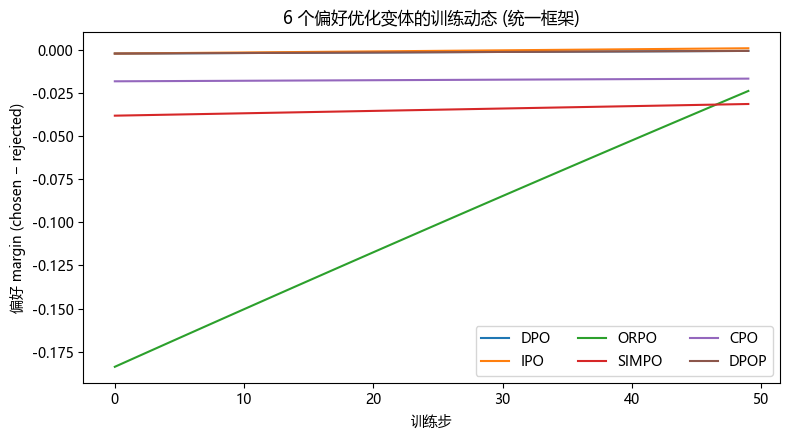

各变体最终 margin:
  DPO    : -0.001
  IPO    : +0.001
  ORPO   : -0.024
  SIMPO  : -0.032
  CPO    : -0.017
  DPOP   : -0.001


In [2]:
import matplotlib, matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus']=False
for f in ['Microsoft YaHei','SimHei','DejaVu Sans']:
    try: matplotlib.rcParams['font.sans-serif']=[f]; break
    except Exception: pass
hist = dc.benchmark(steps=50)
plt.figure(figsize=(8,4.5))
for name in hist:
    plt.plot(hist[name]['margin'], label=name.upper())
plt.xlabel('训练步'); plt.ylabel('偏好 margin (chosen − rejected)'); plt.legend(ncol=3)
plt.title('6 个偏好优化变体的训练动态 (统一框架)'); plt.tight_layout(); plt.show()
print('各变体最终 margin:')
for name in hist: print(f"  {name.upper():7}: {hist[name]['margin'][-1]:+.3f}")

## 2. 反思
- DPO 家族都把「偏好对 (chosen > rejected)」变成可微损失, 不用单独 reward model + PPO。
- 变体差异在: 参考模型 (IPO 无 ref)、长度归一 (SimPO)、SFT 融合 (ORPO/CPO)、防 chosen 概率下降 (DPOP)。
- 本专题各 `*_minimal.py` 是每个变体的最小实现 (真实 gpt2 训练)。